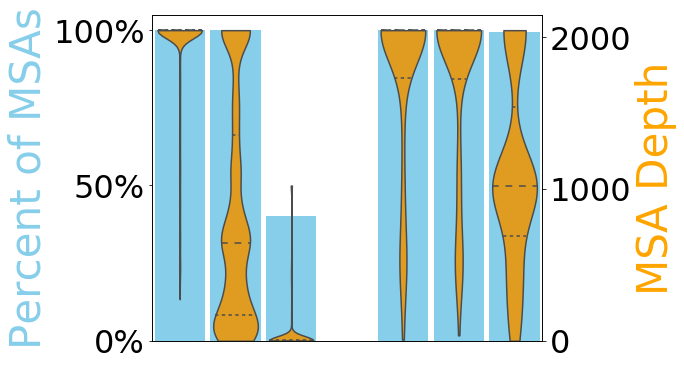

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-pastel")

FONT1 = 32
FONT2 = 42
plt.rcParams.update({"font.size": FONT1})


def _percent_formatter(x, pos):
    return f"{x:.0f}%"


# =============================
# Figure 1F
# =============================
def plot_fig_1f():
    # Inter-species v2h dataset
    dat = pd.read_csv("Fig1F/v2h_binary_MSA_info.txt", sep="\t")
    dat = dat[dat["P1_MSA_depth"] > -1].copy()
#     dat["human_MSA_depth"] = dat[["P1_MSA_depth", "P2_MSA_depth"]].max(axis=1, skipna=False)
#     dat["viral_MSA_depth"] = dat[["P1_MSA_depth", "P2_MSA_depth"]].min(axis=1, skipna=False)
    dat["human_MSA_depth"] = dat[["P1_MSA_depth", "P2_MSA_depth"]].max(axis=1)
    dat["viral_MSA_depth"] = dat[["P1_MSA_depth", "P2_MSA_depth"]].min(axis=1)
    # dat already has 'paired_MSA_depth'

    # Intra-species benchmark dataset
    dat2 = pd.read_csv(
        "Fig1F/Intraspecies_Benchmark_ires_MSA_info.txt", sep="\t"
    )
    dat2 = dat2[dat2["prot1_MSA_depth"] > -1].copy()
    dat2["paired_MSA_depth2"] = dat2["paired_MSA_depth"]

    # Percentages (same as original)
    percentages = [
        dat[dat.human_MSA_depth > 0].shape[0] / dat.shape[0] * 100,
        dat[dat.viral_MSA_depth > 0].shape[0] / dat.shape[0] * 100,
        dat[dat.paired_MSA_depth > 0].shape[0] / dat.shape[0] * 100,
        0,  # spacer
        dat2[dat2.prot1_MSA_depth > 0].shape[0] / dat2.shape[0] * 100,
        dat2[dat2.prot2_MSA_depth > 0].shape[0] / dat2.shape[0] * 100,
        dat2[dat2.paired_MSA_depth2 > 0].shape[0] / dat2.shape[0] * 100,
    ]
    labels = [
        "human_MSA_depth",
        "viral_MSA_depth",
        "paired_MSA_depth",
        "test",
        "prot1_MSA_depth",
        "prot2_MSA_depth",
        "paired_MSA_depth2",
    ]

    fig, ax1 = plt.subplots(figsize=(7, 6))

    # Bars
    ax1.bar(labels, percentages, width=0.9, color="skyblue")
    ax1.set_ylabel("Percent of MSAs", color="skyblue", fontsize=FONT2)
    ax1.set_yticks([0, 50, 100])
    ax1.yaxis.set_major_formatter(FuncFormatter(_percent_formatter))

    # Violin distributions on twin axis
    ax2 = ax1.twinx()

    dat_sub = dat[["human_MSA_depth", "viral_MSA_depth", "paired_MSA_depth"]]
    m1 = dat_sub.melt(var_name="MSA", value_name="Depth")

    dat_sub2 = dat2[
        ["prot1_MSA_depth", "prot2_MSA_depth", "paired_MSA_depth2"]
    ]
    m2 = dat_sub2.melt(var_name="MSA", value_name="Depth")

    melted_all = pd.concat([m1, m2], ignore_index=True)

    # Single call with full order => keeps inter- and intra-species visible
    sns.violinplot(
        x="MSA",
        y="Depth",
        data=melted_all,
        order=labels,          # includes 'test' gap
        cut=0,
        scale="width",
        ax=ax2,
        color="orange",
        inner="quart",
    )

    ax2.set_ylabel("MSA Depth", color="orange", fontsize=FONT2)
    ax2.set_ylim(bottom=0)
    ax2.set_xticks([])        # hide category names; bars define structure
    ax2.set_yticks([0, 1000, 2000])

    fig.savefig("Fig1F/MSA_percents.svg", format="svg", bbox_inches="tight")
    plt.show()

plot_fig_1f()

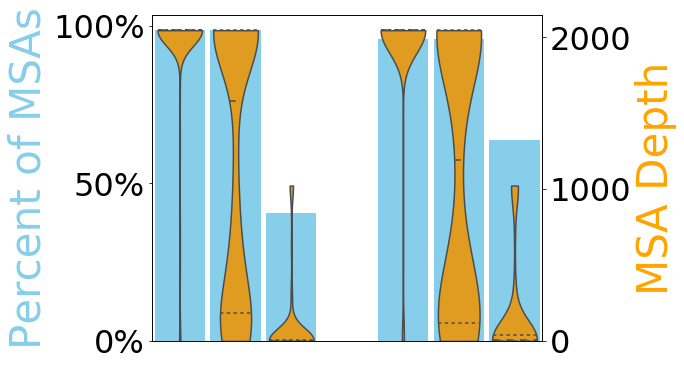

In [15]:
# =============================
# Figure S1A
# =============================
def plot_fig_s1a():
    dat = pd.read_csv("FigS1A/viral_human_510_integrated.txt", sep="\t")

    dat_virus = dat[dat["Domain"] == "Viruses"].copy()
    dat_bact = dat[dat["Domain"] == "Bacteria"].copy()

    dat_bact["human_MSA_depth2"] = dat_bact["human_MSA_depth"]
    dat_bact["bacteria_MSA_depth2"] = dat_bact["viral_MSA_depth"]
    dat_bact["paired_MSA_depth2"] = dat_bact["paired_MSA_depth"]

    percentages = [
        dat_virus[dat_virus.human_MSA_depth > 0].shape[0] / dat_virus.shape[0] * 100,
        dat_virus[dat_virus.viral_MSA_depth > 0].shape[0] / dat_virus.shape[0] * 100,
        dat_virus[dat_virus.paired_MSA_depth > 0].shape[0] / dat_virus.shape[0] * 100,
        0,
        dat_bact[dat_bact.human_MSA_depth2 > 0].shape[0] / dat_bact.shape[0] * 100,
        dat_bact[dat_bact.bacteria_MSA_depth2 > 0].shape[0]
        / dat_bact.shape[0]
        * 100,
        dat_bact[dat_bact.paired_MSA_depth2 > 0].shape[0] / dat_bact.shape[0] * 100,
    ]
    labels = [
        "human_MSA_depth",
        "viral_MSA_depth",
        "paired_MSA_depth",
        "test",
        "human_MSA_depth2",
        "bacteria_MSA_depth2",
        "paired_MSA_depth2",
    ]

    fig, ax1 = plt.subplots(figsize=(7, 6))

    # Bars
    ax1.bar(labels, percentages, width=0.9, color="skyblue")
    ax1.set_ylabel("Percent of MSAs", color="skyblue", fontsize=FONT2)
    ax1.set_yticks([0, 50, 100])
    ax1.yaxis.set_major_formatter(FuncFormatter(_percent_formatter))

    # Violins
    ax2 = ax1.twinx()

    dat_sub = dat[["human_MSA_depth", "viral_MSA_depth", "paired_MSA_depth"]]
    m1 = dat_sub.melt(var_name="MSA", value_name="Depth")

    dat_sub2 = dat_bact[
        ["human_MSA_depth2", "bacteria_MSA_depth2", "paired_MSA_depth2"]
    ]
    m2 = dat_sub2.melt(var_name="MSA", value_name="Depth")

    melted_all = pd.concat([m1, m2], ignore_index=True)

    sns.violinplot(
        x="MSA",
        y="Depth",
        data=melted_all,
        order=labels,          # keeps virus + bacteria categories + gap
        cut=0,
        ax=ax2,
        scale="width",
        color="orange",
        inner="quart",
    )

    ax2.set_ylabel("MSA Depth", color="orange", fontsize=FONT2)
    ax2.set_ylim(bottom=0)
    ax2.set_xticks([])
    ax2.set_yticks([0, 1000, 2000])

    fig.savefig(
        "FigS1A/MSA_viral_bacteria_percents.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()
    
plot_fig_s1a()